<a href="https://colab.research.google.com/github/KANGWEII/hands_on_ml/blob/feature-chapter_9/Chapter09/unsupervised_learning_techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 9: Unsupervised Learning Techniques

Unsupervised learning tasks:
- Dimensionality reduction (Chapter 08)
- Clustering
- Anomaly detection
- Density estimation

## Clustering Algorithms: k-means and DBSCAN

- Clustering is the task of identifying similar instances and assigning them to clusters, or groups of similar instances
- Like classification, but each instance is not labeled

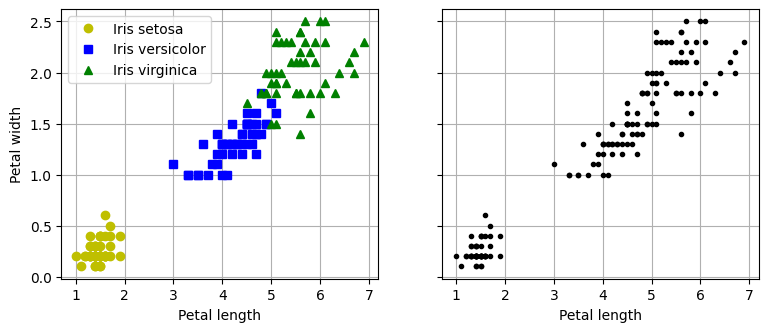

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

data = load_iris()
X = data.data
y = data.target
data.target_names

plt.figure(figsize=(9, 3.5))

plt.subplot(121)
plt.plot(X[y==0, 2], X[y==0, 3], "yo", label="Iris setosa")
plt.plot(X[y==1, 2], X[y==1, 3], "bs", label="Iris versicolor")
plt.plot(X[y==2, 2], X[y==2, 3], "g^", label="Iris virginica")
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.grid()
plt.legend()

plt.subplot(122)
plt.scatter(X[:, 2], X[:, 3], c="k", marker=".")
plt.xlabel("Petal length")
plt.tick_params(labelleft=False)
plt.gca().set_axisbelow(True)
plt.grid()

plt.show()

### k-means

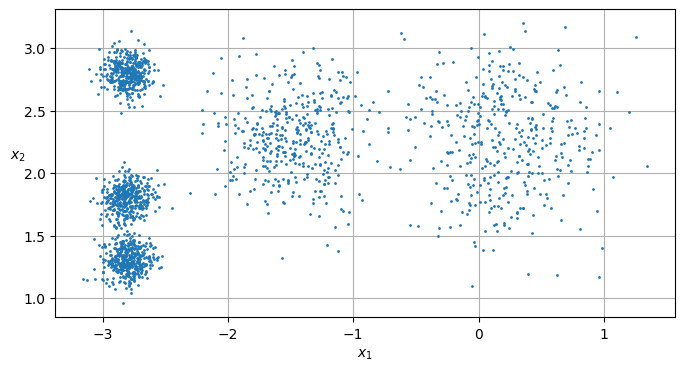

In [2]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import numpy as np

blob_centers = np.array([[ 0.2,  2.3], [-1.5 ,  2.3], [-2.8,  1.8],
                         [-2.8,  2.8], [-2.8,  1.3]])
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])
X, y = make_blobs(n_samples=2000, centers=blob_centers, cluster_std=blob_std,
                  random_state=7)

# Specify number of clusters k that the algorithm must find
k = 5
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
y_pred = kmeans.fit_predict(X)

def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$", rotation=0)

plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.gca().set_axisbelow(True)
plt.grid()
plt.show()

In [3]:
y_pred

array([0, 0, 4, ..., 3, 1, 0], dtype=int32)

In [4]:
y_pred is kmeans.labels_

True

In [5]:
# 5 centroids
kmeans.cluster_centers_

array([[-2.80214068,  1.55162671],
       [ 0.08703534,  2.58438091],
       [-1.46869323,  2.28214236],
       [-2.79290307,  2.79641063],
       [ 0.31332823,  1.96822352]])

In [6]:
# Example on assigning new instances

import numpy as np

X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])
kmeans.predict(X_new)

array([4, 4, 3, 3], dtype=int32)

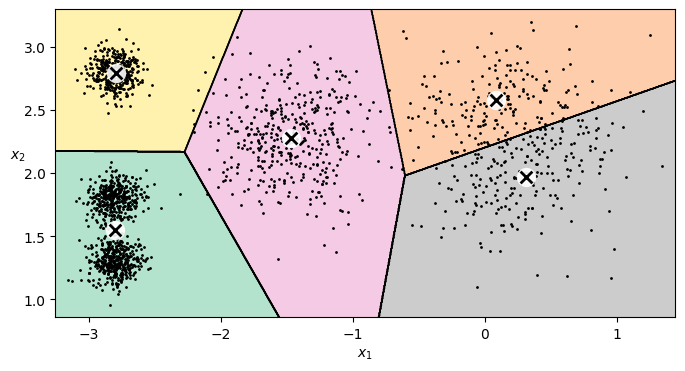

In [7]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=35, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=2, linewidths=12,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True,
                             show_xlabels=True, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")
    plt.contour(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                linewidths=1, colors='k')
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    if show_xlabels:
        plt.xlabel("$x_1$")
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)

plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.show()

- Majority of the instances were clearly assigned
- Hard clustering
  - Assigning each instance to a single custer
- Soft clustering
  - Give each instance a score per cluster
  - Score can be the distance between the instance and the centroid
  - Using transform()

In [8]:
kmeans.transform(X_new).round(2)

array([[2.84, 0.59, 1.5 , 2.9 , 0.31],
       [5.82, 2.97, 4.48, 5.85, 2.69],
       [1.46, 3.11, 1.69, 0.29, 3.47],
       [0.97, 3.09, 1.55, 0.36, 3.36]])

In [9]:
# Verify that transform is indeed Euclidian distance

np.linalg.norm(np.tile(X_new, (1, k)).reshape(-1, k, 2)
               - kmeans.cluster_centers_, axis=2).round(2)

array([[2.84, 0.59, 1.5 , 2.9 , 0.31],
       [5.82, 2.97, 4.48, 5.85, 2.69],
       [1.46, 3.11, 1.69, 0.29, 3.47],
       [0.97, 3.09, 1.55, 0.36, 3.36]])

#### The k-means algorithm

1. Place the centroids randomly
2. Assign each instance to the closest centroid
3. Compute the mean of all instances assigned to the centroid
4. Move the centroid to the new mean
5. Repeat step 2 to 5 until converge

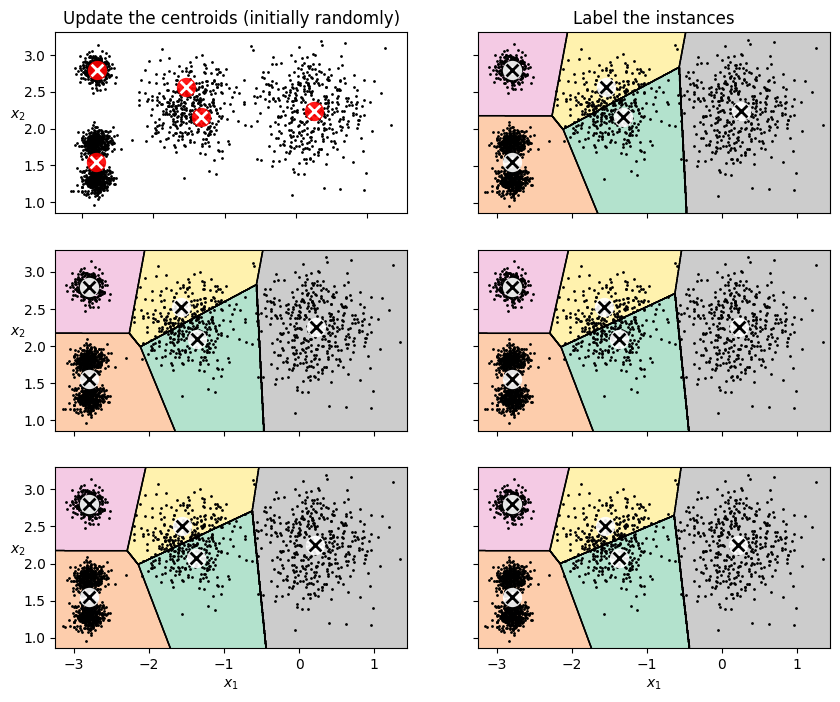

In [10]:
kmeans_iter1 = KMeans(n_clusters=5, init="random", n_init=1, max_iter=1,
                      random_state=5)
kmeans_iter2 = KMeans(n_clusters=5, init="random", n_init=1, max_iter=2,
                      random_state=5)
kmeans_iter3 = KMeans(n_clusters=5, init="random", n_init=1, max_iter=3,
                      random_state=5)
kmeans_iter1.fit(X)
kmeans_iter2.fit(X)
kmeans_iter3.fit(X)

plt.figure(figsize=(10, 8))

plt.subplot(321)
plot_data(X)
plot_centroids(kmeans_iter1.cluster_centers_, circle_color='r', cross_color='w')
plt.ylabel("$x_2$", rotation=0)
plt.tick_params(labelbottom=False)
plt.title("Update the centroids (initially randomly)")

plt.subplot(322)
plot_decision_boundaries(kmeans_iter1, X, show_xlabels=False,
                         show_ylabels=False)
plt.title("Label the instances")

plt.subplot(323)
plot_decision_boundaries(kmeans_iter1, X, show_centroids=False,
                         show_xlabels=False)
plot_centroids(kmeans_iter2.cluster_centers_)

plt.subplot(324)
plot_decision_boundaries(kmeans_iter2, X, show_xlabels=False,
                         show_ylabels=False)

plt.subplot(325)
plot_decision_boundaries(kmeans_iter2, X, show_centroids=False)
plot_centroids(kmeans_iter3.cluster_centers_)

plt.subplot(326)
plot_decision_boundaries(kmeans_iter3, X, show_ylabels=False)

plt.show()

- Algorithm is guaranteed to converge, but it depends on the centroid initialization
- Centroids can converge to very different solutions

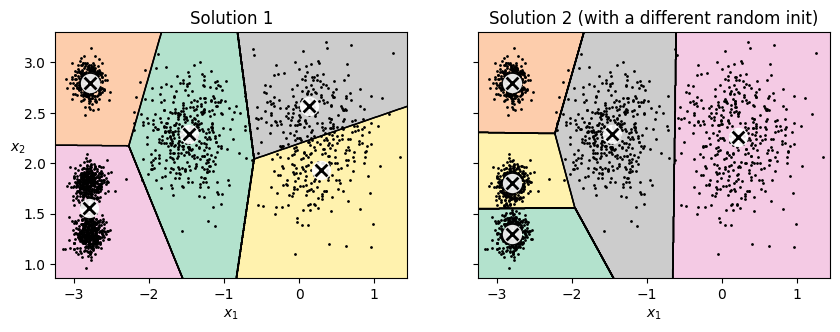

In [11]:
def plot_clusterer_comparison(clusterer1, clusterer2, X, title1=None,
                              title2=None):
    clusterer1.fit(X)
    clusterer2.fit(X)

    plt.figure(figsize=(10, 3.2))

    plt.subplot(121)
    plot_decision_boundaries(clusterer1, X)
    if title1:
        plt.title(title1)

    plt.subplot(122)
    plot_decision_boundaries(clusterer2, X, show_ylabels=False)
    if title2:
        plt.title(title2)

kmeans_rnd_init1 = KMeans(n_clusters=5, init="random", n_init=1, random_state=2)
kmeans_rnd_init2 = KMeans(n_clusters=5, init="random", n_init=1, random_state=9)

plot_clusterer_comparison(kmeans_rnd_init1, kmeans_rnd_init2, X,
                          "Solution 1",
                          "Solution 2 (with a different random init)")

plt.show()

#### Centroid initialization methods

- Mitigate the above issue of random initialization
- If happen to know approximately where the centroids should be, can set the init hyperparameter to a NumPy array

In [12]:
good_init = np.array([[-3, 3], [-3, 2], [-3, 1], [-1, 2], [0, 2]])
kmeans = KMeans(n_clusters=5, init=good_init, n_init=1, random_state=42)
kmeans.fit(X)

KMeans(init=array([[-3,  3],
       [-3,  2],
       [-3,  1],
       [-1,  2],
       [ 0,  2]]),
       n_clusters=5, n_init=1, random_state=42)

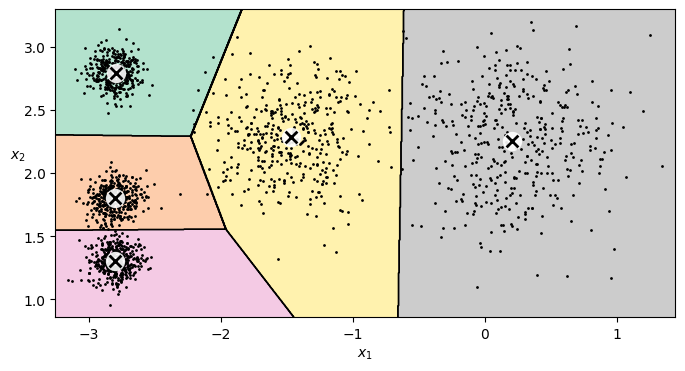

In [13]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)

- Another solution is to run the algorithm multiple times with different random initializations and keep the best solution
- Number of random initializations is controlled by the n_init hyperparameter, default is 10
- Which solution is the best?
  - Use performance metric (model's inertia)
  - Which is the sum of the squared distances between the instances and their closest centroids

In [14]:
kmeans.inertia_

211.59853725816828

In [15]:
kmeans_rnd_init1.inertia_

219.58201503602285

In [16]:
kmeans_rnd_init2.inertia_

211.59853725816828

In [17]:
# Sum of the squared distances

X_dist = kmeans.transform(X)
(X_dist[np.arange(len(X_dist)), kmeans.labels_] ** 2).sum()

np.float64(211.59853725816882)

In [18]:
kmeans.score(X)

-211.59853725816828

- Why negative?
  - Predictor's score() method must always respect the "greater is better" rule

Improvement to the k-means algorithm, k-means++, smarter initialization step that leads to select centroids that are distant from one another
1. Take one centroid $c^{(1)}$, chosen uniformly at random from the dataset
2. Take a new centroid $c^{(i)}$, choosing an instance $x^{(i)}$ with probability $\frac{D(x^{(i)})^2}{∑^m_{j=1}D(x^{(j)})^2}$, where $D(x^{(i)})$ is the distance between the instance $x^{(i)}$ and the closest centroid that was already chosen. This probability distribution ensures that instances farther away from already chosen centroids are much more likely to be selected as centroids.
3. Repeat the previous step until all $k$ centroids have been chosen.

- The KMeans class uses this initialization method by default

#### Accelerated k-means and mini-batch k-means

- The K-Means algorithm can sometimes be accelerated by avoiding many unnecessary distance calculations: this is achieved by exploiting the triangle inequality (given three points A, B and C, the distance AC is always such that AC ≤ AB + BC) and by keeping track of lower and upper bounds for distances between instances and centroids
- For Elkan's variant of K-Means, use algorithm="elkan"

- Scikit-Learn also implements a variant of the K-Means algorithm that supports mini-batches

In [19]:
from sklearn.cluster import MiniBatchKMeans

minibatch_kmeans = MiniBatchKMeans(n_clusters=5, random_state=42)
minibatch_kmeans.fit(X)

MiniBatchKMeans(n_clusters=5, random_state=42)

- If the datatset does not fit in memory, simplest option is to use the memmap class (example in Chapter 8, incremental PCA)

In [20]:
minibatch_kmeans.inertia_

211.65945105712612

In [21]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False, parser="auto")

In [22]:
X_train, y_train = mnist.data[:60000], mnist.target[:60000]
X_test, y_test = mnist.data[60000:], mnist.target[60000:]

In [23]:
filename = "my_mnist.mmap"
X_memmap = np.memmap(filename, dtype='float32', mode='write',
                     shape=X_train.shape)
X_memmap[:] = X_train
X_memmap.flush()

In [24]:
from sklearn.cluster import MiniBatchKMeans

minibatch_kmeans = MiniBatchKMeans(n_clusters=10, batch_size=10,
                                   n_init=3, random_state=42)
minibatch_kmeans.fit(X_memmap)

MiniBatchKMeans(batch_size=10, n_clusters=10, n_init=3, random_state=42)

100/100

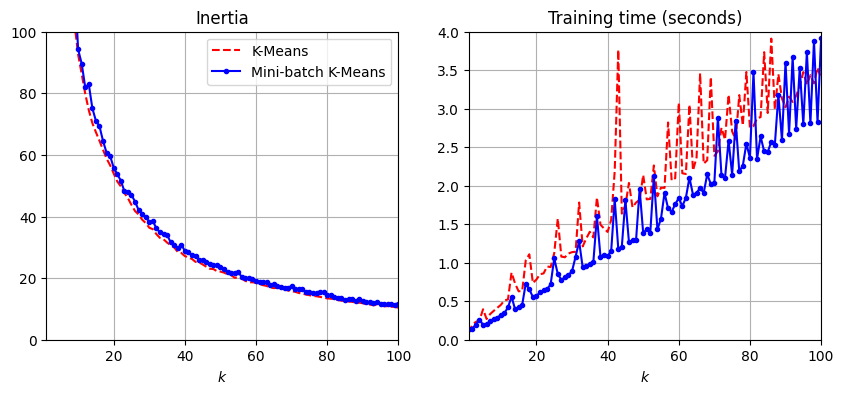

In [25]:
# Inertia ratio and the training time ratio between Mini-batch K-Means and regular K-Means

from timeit import timeit

max_k = 100
times = np.empty((max_k, 2))
inertias = np.empty((max_k, 2))
for k in range(1, max_k + 1):
    kmeans_ = KMeans(n_clusters=k, algorithm="lloyd", n_init=10, random_state=42)
    minibatch_kmeans = MiniBatchKMeans(n_clusters=k, n_init=10, random_state=42)
    print(f"\r{k}/{max_k}", end="")  # \r returns to the start of line
    times[k - 1, 0] = timeit("kmeans_.fit(X)", number=10, globals=globals())
    times[k - 1, 1] = timeit("minibatch_kmeans.fit(X)", number=10,
                             globals=globals())
    inertias[k - 1, 0] = kmeans_.inertia_
    inertias[k - 1, 1] = minibatch_kmeans.inertia_

plt.figure(figsize=(10, 4))

plt.subplot(121)
plt.plot(range(1, max_k + 1), inertias[:, 0], "r--", label="K-Means")
plt.plot(range(1, max_k + 1), inertias[:, 1], "b.-", label="Mini-batch K-Means")
plt.xlabel("$k$")
plt.title("Inertia")
plt.legend()
plt.axis([1, max_k, 0, 100])
plt.grid()

plt.subplot(122)
plt.plot(range(1, max_k + 1), times[:, 0], "r--", label="K-Means")
plt.plot(range(1, max_k + 1), times[:, 1], "b.-", label="Mini-batch K-Means")
plt.xlabel("$k$")
plt.title("Training time (seconds)")
plt.axis([1, max_k, 0, 4])
plt.grid()

plt.show()

- mini-batch k-means algorithm is much faster than the regular k-means algorithm, its inertia is generally slightly worse

#### Finding the optimal number of clusters

- Inertia is not a good performance metric for choosing the number of clusters, $k$
- Inertia decreases as $k$ increases
- To find the optimal $k$, plot the inertia as a function of $k$
 and analyze the resulting curve:

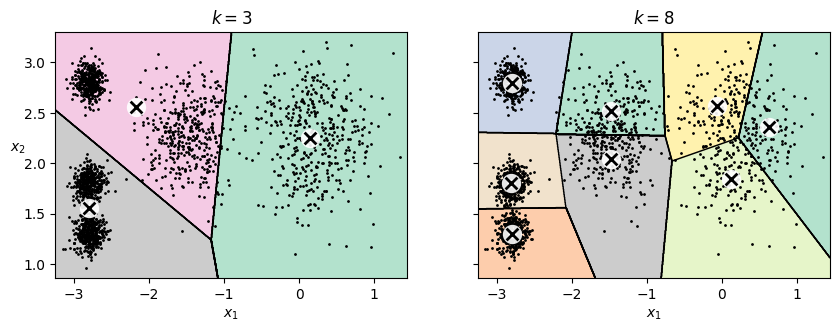

In [26]:
kmeans_k3 = KMeans(n_clusters=3, n_init=10, random_state=42)
kmeans_k8 = KMeans(n_clusters=8, n_init=10, random_state=42)

plot_clusterer_comparison(kmeans_k3, kmeans_k8, X, "$k=3$", "$k=8$")
plt.show()

In [27]:
print("k=3, inertia=", kmeans_k3.inertia_)
print("k=8, inertia=", kmeans_k8.inertia_)

k=3, inertia= 653.2167190021554
k=8, inertia= 119.22484592677135


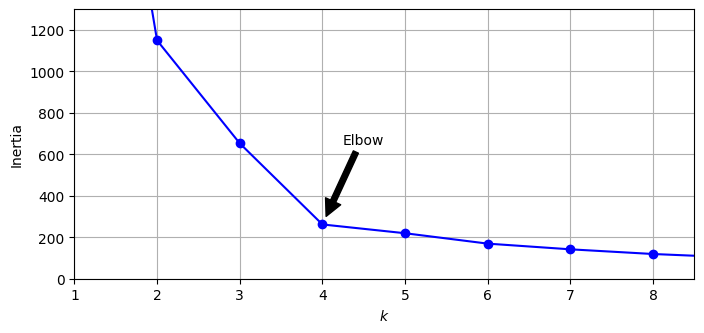

In [28]:
kmeans_per_k = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
                for k in range(1, 10)]
inertias = [model.inertia_ for model in kmeans_per_k]

plt.figure(figsize=(8, 3.5))
plt.plot(range(1, 10), inertias, "bo-")
plt.xlabel("$k$")
plt.ylabel("Inertia")
plt.annotate("", xy=(4, inertias[3]), xytext=(4.45, 650),
             arrowprops=dict(facecolor='black', shrink=0.1))
plt.text(4.5, 650, "Elbow", horizontalalignment="center")
plt.axis([1, 8.5, 0, 1300])
plt.grid()
plt.show()

- There is an elbow at $k=4$, which means that less clusters than that would be bad, and more clusters would not help much and might cut clusters in half. So $k=4$ is a pretty good choice.

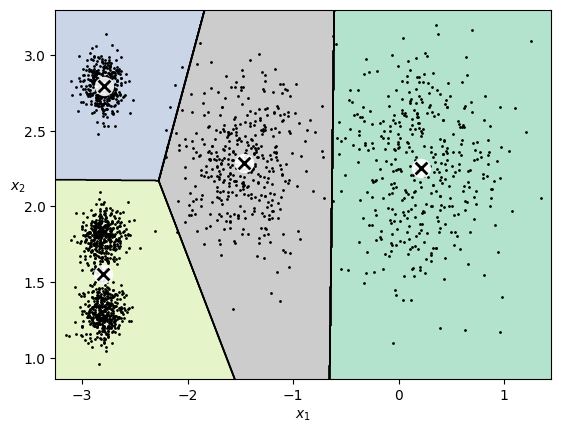

In [29]:
plot_decision_boundaries(kmeans_per_k[4 - 1], X)
plt.show()

- A more precise approach is to use the silhouette score, which is the mean silhouette coefficient over all the instances
- An instance's silhouette coefficient:
$$
\frac{b-a}{max(a,b)}
$$

  where
  - a = mean distance to the other instances in the same cluster
  - b = mean nearest-cluster distance
- Silhouette coefficient vary between -1 and +1
- Coefficient close to +1 means that the instance is well inside its own cluster and far from other clusters
- 0 means close to a cluster boundary
- -1 means the instance may have been assigned to the wrong cluster

In [30]:
from sklearn.metrics import silhouette_score

silhouette_score(X, kmeans.labels_)

np.float64(0.655517642572828)

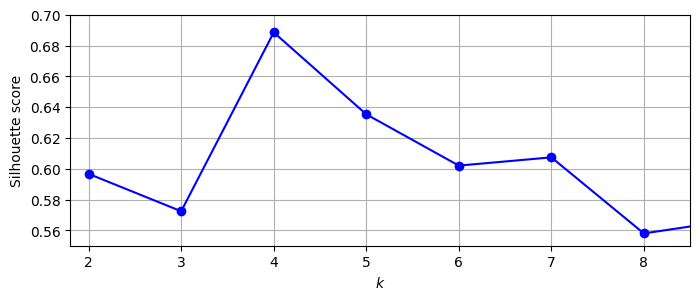

In [31]:
# Compare silhouette scores for different number of clusters

silhouette_scores = [silhouette_score(X, model.labels_)
                     for model in kmeans_per_k[1:]]

plt.figure(figsize=(8, 3))
plt.plot(range(2, 10), silhouette_scores, "bo-")
plt.xlabel("$k$")
plt.ylabel("Silhouette score")
plt.axis([1.8, 8.5, 0.55, 0.7])
plt.grid()
plt.show()

- Confirms that $k=4$ is a very good choice, and also highlights the fact that $k=5$ is quite good as well
- Plot silhouette diagram to visualize every instance's silhouette coefficient, sorted by the clusters they are assigned to and by the value of the coefficient

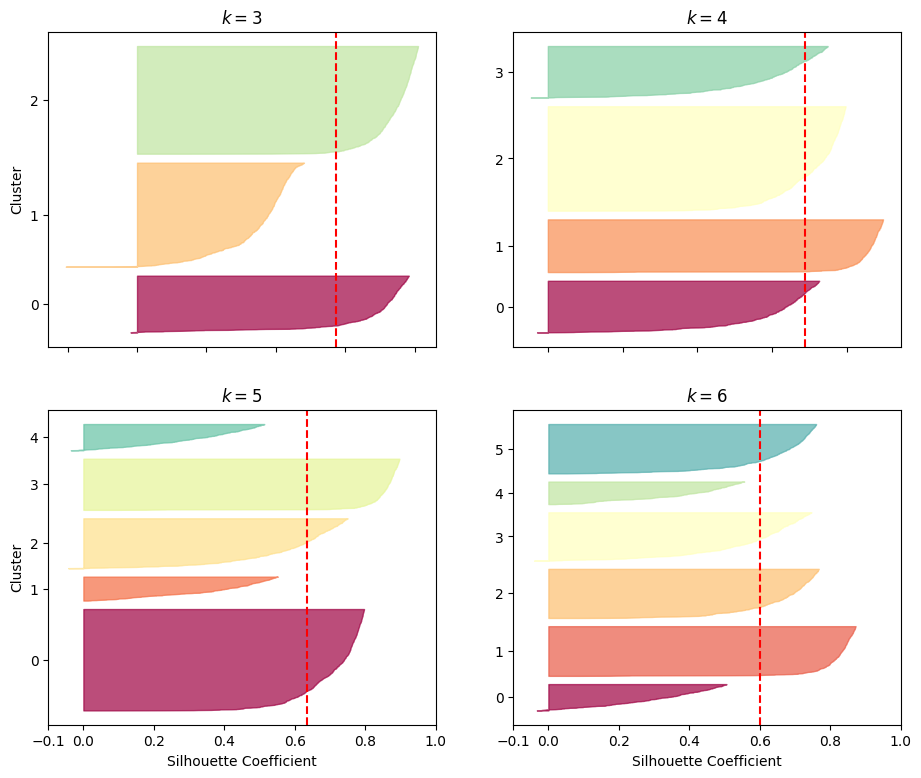

In [32]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter

plt.figure(figsize=(11, 9))

for k in (3, 4, 5, 6):
    plt.subplot(2, 2, k - 2)

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = plt.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5):
        plt.ylabel("Cluster")

    if k in (5, 6):
        plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient")
    else:
        plt.tick_params(labelbottom=False)

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title(f"$k={k}$")

plt.show()

### Limits of k-means

- Does not behave well when the clusters have varying sizes, different densities, or nonspherical shapes

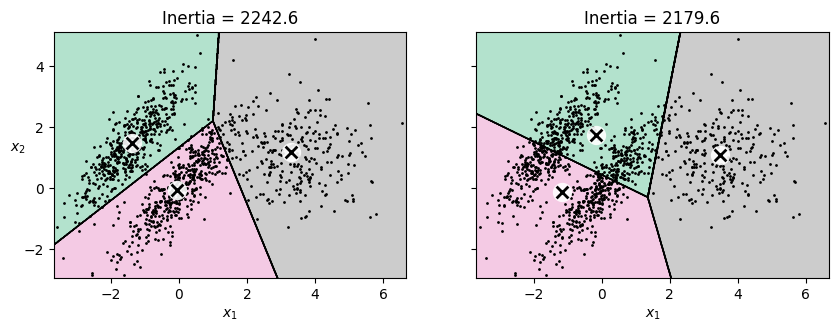

In [33]:
X1, y1 = make_blobs(n_samples=1000, centers=((4, -4), (0, 0)), random_state=42)
X1 = X1.dot(np.array([[0.374, 0.95], [0.732, 0.598]]))
X2, y2 = make_blobs(n_samples=250, centers=1, random_state=42)
X2 = X2 + [6, -8]
X = np.r_[X1, X2]
y = np.r_[y1, y2]

kmeans_good = KMeans(n_clusters=3,
                     init=np.array([[-1.5, 2.5], [0.5, 0], [4, 0]]),
                     n_init=1, random_state=42)
kmeans_bad = KMeans(n_clusters=3, n_init=10, random_state=42)
kmeans_good.fit(X)
kmeans_bad.fit(X)

plt.figure(figsize=(10, 3.2))

plt.subplot(121)
plot_decision_boundaries(kmeans_good, X)
plt.title(f"Inertia = {kmeans_good.inertia_:.1f}")

plt.subplot(122)
plot_decision_boundaries(kmeans_bad, X, show_ylabels=False)
plt.title(f"Inertia = {kmeans_bad.inertia_:.1f}")

plt.show()

- Figure on the right is better but still chop off 25% of the middle cluster and assigns it to the cluster on the right
- Figure on the right is just terrible
- On these types of elliptical clusters, Gaussian mixture models work great

### Using Clustering for Image Segmentation

- Color segmentation
  - Pixels with similar color get assigned to the same segment
- Semantic segmentation
  - Pixels that are part of the same object type get assigned to the same segment
- Instance segmentation
  - Pixels that are part of the same individual object are assigned to the same segment

- Semantic or instance segmentation today is achieved using complex architectures based on convolutional neural networks

In [34]:
import urllib.request
import os
import numpy as np
from PIL import Image

filename = "ladybug.png"
url = "https://github.com//KANGWEII/hands_on_ml/blob/feature-chapter_9/Chapter09/Img/" + filename + "?raw=true"

if os.path.exists(filename):
    os.remove(filename)

urllib.request.urlretrieve(url, filename)

('ladybug.png', <http.client.HTTPMessage at 0x7d9afc576fc0>)

In [35]:
image = np.asarray(Image.open(filename))
print("Image shape:", image.shape)

Image shape: (533, 800, 3)


In [36]:
X = image.reshape(-1, 3)
kmeans = KMeans(n_clusters=8, random_state=42).fit(X)
segmented_img = kmeans.cluster_centers_[kmeans.labels_]
segmented_img = segmented_img.reshape(image.shape)

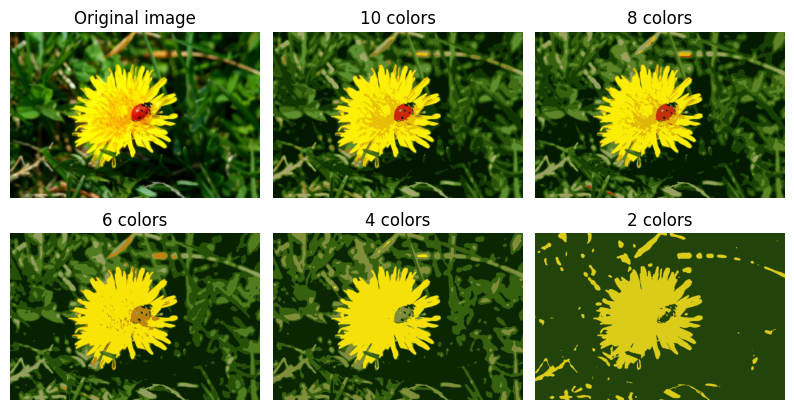

In [37]:
segmented_imgs = []
n_colors = (10, 8, 6, 4, 2)
for n_clusters in n_colors:
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42).fit(X)
    segmented_img = kmeans.cluster_centers_[kmeans.labels_]
    segmented_imgs.append(segmented_img.reshape(image.shape))

plt.figure(figsize=(10, 5))
plt.subplots_adjust(wspace=0.05, hspace=0.1)

plt.subplot(2, 3, 1)
plt.imshow(image)
plt.title("Original image")
plt.axis('off')

for idx, n_clusters in enumerate(n_colors):
    plt.subplot(2, 3, 2 + idx)
    plt.imshow(segmented_imgs[idx] / 255)
    plt.title(f"{n_clusters} colors")
    plt.axis('off')

plt.show()

### Using Clustering for Semi-Supervised Learning

In [38]:
from sklearn.datasets import load_digits

X_digits, y_digits = load_digits(return_X_y=True)
X_train, y_train = X_digits[:1400], y_digits[:1400]
X_test, y_test = X_digits[1400:], y_digits[1400:]

In [39]:
from sklearn.linear_model import LogisticRegression

n_labeled = 50
log_reg = LogisticRegression(max_iter=10000)
log_reg.fit(X_train[:n_labeled], y_train[:n_labeled])
log_reg.score(X_test, y_test)

0.7581863979848866

In [40]:
# Full dataset training

log_reg_full = LogisticRegression(max_iter=10000)
log_reg_full.fit(X_train, y_train)
log_reg_full.score(X_test, y_test)

0.9093198992443325

In [41]:
k = 50
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
X_digits_dist = kmeans.fit_transform(X_train)
representative_digit_idx = X_digits_dist.argmin(axis=0)
X_representative_digits = X_train[representative_digit_idx]

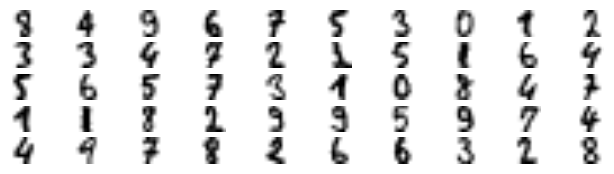

In [42]:
plt.figure(figsize=(8, 2))
for index, X_representative_digit in enumerate(X_representative_digits):
    plt.subplot(k // 10, 10, index + 1)
    plt.imshow(X_representative_digit.reshape(8, 8), cmap="binary",
               interpolation="bilinear")
    plt.axis('off')

plt.show()

In [43]:
y_representative_digits = np.array([
     8, 4, 9, 6, 7, 5, 3, 0, 1, 2,
     3, 3, 4, 7, 2, 1, 5, 1, 6, 4,
     5, 6, 5, 7, 3, 1, 0, 8, 4, 7,
     1, 1, 8, 2, 9, 9, 5, 9, 7, 4,
     4, 9, 7, 8, 2, 6, 6, 3, 2, 8
])
# Now we have a dataset with just 50 labeled instances, but instead of being completely random instances, each of them is a representative image of its cluster.

In [44]:
log_reg = LogisticRegression(max_iter=10000)
log_reg.fit(X_representative_digits, y_representative_digits)
log_reg.score(X_test, y_test)

0.8387909319899244

- What is we propagated the labels to all the other instances in the same cluster?
- Label propagation:

In [45]:
y_train_propagated = np.empty(len(X_train), dtype=np.int64)
for i in range(k):
    y_train_propagated[kmeans.labels_ == i] = y_representative_digits[i]

log_reg = LogisticRegression(max_iter=10000)
log_reg.fit(X_train, y_train_propagated)

log_reg.score(X_test, y_test)

0.8589420654911839

- Ignoring the 1% instances that are farthest from their cluster center
- Eliminate some outliers

In [46]:
percentile_closest = 99

X_cluster_dist = X_digits_dist[np.arange(len(X_train)), kmeans.labels_]
for i in range(k):
    in_cluster = (kmeans.labels_ == i)
    cluster_dist = X_cluster_dist[in_cluster]
    cutoff_distance = np.percentile(cluster_dist, percentile_closest)
    above_cutoff = (X_cluster_dist > cutoff_distance)
    X_cluster_dist[in_cluster & above_cutoff] = -1

partially_propagated = (X_cluster_dist != -1)
X_train_partially_propagated = X_train[partially_propagated]
y_train_partially_propagated = y_train_propagated[partially_propagated]

In [47]:
log_reg = LogisticRegression(max_iter=10000)
log_reg.fit(X_train_partially_propagated, y_train_partially_propagated)
log_reg.score(X_test, y_test)

0.8564231738035264

Propagated labels are actually pretty good:

In [48]:
(y_train_partially_propagated == y_train[partially_propagated]).mean()

np.float64(0.9548148148148148)

### DBSCAN

- Density-Based Spatial Clustering of Applications with Noise (DBSCAN)
- Defines clusters as continuous regions of high density

In [49]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=1000, noise=0.05)
dbscan = DBSCAN(eps=0.05, min_samples=5)
dbscan.fit(X)

DBSCAN(eps=0.05)

In [50]:
# Labels of all the instances
# Index equal to -1 is considered as anomalies
dbscan.labels_

array([ 0, -1,  1,  2, -1,  3, -1,  0,  3,  0,  0,  4, -1,  0,  2,  0,  0,
        0,  4,  0,  4, -1,  0,  0,  2,  1,  4,  4,  0,  2,  0,  0,  2,  0,
        0,  2,  4,  4,  0,  1,  4,  1,  2,  0,  1,  0,  0,  2,  4,  5,  4,
        0,  5,  0,  0, -1,  4,  0,  3,  0,  3,  1,  0,  0,  4,  0,  0,  3,
        0,  2,  1,  0, -1,  0,  3,  6, -1,  1,  1,  0, -1,  2,  5,  4,  0,
        0,  0,  4,  2, -1,  0,  0,  0,  6,  5,  0,  2, -1,  0, -1,  5,  4,
        2, -1,  0,  0,  0, -1,  2,  2,  3,  0,  2,  1,  0,  0,  0,  2,  5,
        2,  1,  0,  2,  0,  2,  0,  2,  0,  0,  2,  1,  0, -1,  1,  0,  1,
        1,  3,  3,  1,  4,  0,  4, -1,  2,  1,  2,  4,  0,  0,  2,  4,  6,
        1,  0, -1,  0,  1,  4, -1,  0,  2,  1,  0,  2,  4,  5,  0,  0,  3,
        0,  5,  0,  2,  0,  3, -1,  0,  5,  2,  0,  7,  1,  4,  0,  4,  3,
        1,  4, -1,  5,  3,  4,  4, -1,  2,  4,  2,  0,  0,  5,  0,  0,  0,
       -1, -1,  2,  0,  4, -1,  0,  0,  0,  4,  0, -1,  6,  0,  0,  0,  4,
        0, -1,  0,  4,  0

In [51]:
# Indices of the core instances
dbscan.core_sample_indices_

array([  0,   2,   3,   5,   7,   8,   9,  11,  14,  15,  16,  17,  18,
        19,  20,  22,  23,  24,  25,  26,  27,  28,  29,  30,  31,  32,
        33,  34,  35,  36,  37,  38,  39,  40,  42,  43,  44,  45,  47,
        48,  49,  50,  51,  52,  53,  54,  56,  57,  58,  59,  60,  61,
        62,  64,  65,  66,  67,  68,  69,  70,  71,  73,  74,  77,  78,
        79,  82,  83,  84,  85,  86,  87,  88,  90,  91,  92,  94,  95,
        96,  98, 100, 101, 102, 104, 109, 110, 111, 112, 113, 114, 115,
       116, 117, 119, 120, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 133, 134, 135, 136, 137, 138, 139, 141, 142, 144, 145, 146,
       147, 148, 149, 150, 151, 152, 156, 157, 158, 160, 161, 163, 164,
       165, 166, 167, 168, 169, 170, 172, 173, 174, 177, 178, 179, 182,
       183, 184, 185, 186, 187, 188, 190, 191, 193, 195, 196, 197, 198,
       199, 200, 201, 202, 203, 206, 207, 208, 210, 211, 212, 213, 216,
       217, 220, 221, 223, 224, 225, 227, 228, 229, 230, 232, 23

In [52]:
# Core instances
dbscan.components_

array([[ 1.89184267, -0.01581307],
       [ 0.46256377,  0.88662953],
       [ 0.87899803,  0.3953086 ],
       ...,
       [ 0.09603972,  0.14970608],
       [ 1.14501474, -0.39899786],
       [ 0.64249157, -0.46161498]])

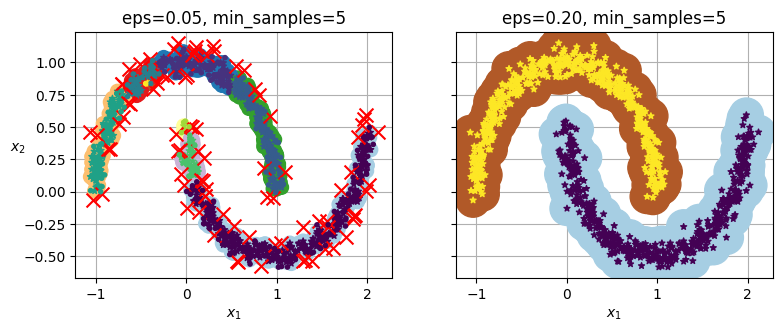

In [53]:
def plot_dbscan(dbscan, X, size, show_xlabels=True, show_ylabels=True):
    core_mask = np.zeros_like(dbscan.labels_, dtype=bool)
    core_mask[dbscan.core_sample_indices_] = True
    anomalies_mask = dbscan.labels_ == -1
    non_core_mask = ~(core_mask | anomalies_mask)

    cores = dbscan.components_
    anomalies = X[anomalies_mask]
    non_cores = X[non_core_mask]

    plt.scatter(cores[:, 0], cores[:, 1],
                c=dbscan.labels_[core_mask], marker='o', s=size, cmap="Paired")
    plt.scatter(cores[:, 0], cores[:, 1], marker='*', s=20,
                c=dbscan.labels_[core_mask])
    plt.scatter(anomalies[:, 0], anomalies[:, 1],
                c="r", marker="x", s=100)
    plt.scatter(non_cores[:, 0], non_cores[:, 1],
                c=dbscan.labels_[non_core_mask], marker=".")
    if show_xlabels:
        plt.xlabel("$x_1$")
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)
    plt.title(f"eps={dbscan.eps:.2f}, min_samples={dbscan.min_samples}")
    plt.grid()
    plt.gca().set_axisbelow(True)

dbscan2 = DBSCAN(eps=0.2)
dbscan2.fit(X)

plt.figure(figsize=(9, 3.2))

plt.subplot(121)
plot_dbscan(dbscan, X, size=100)

plt.subplot(122)
plot_dbscan(dbscan2, X, size=600, show_ylabels=False)

plt.show()

- DBSCAN class cannot predict which cluster a new instance belongs to
- The following shows how to implement prediction with DBSCAN using KNeighborsClassifier

In [54]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_])

# Provide new instances
X_new = np.array([[-0.5,0], [0,0.5], [1,-0.1], [2,1]])

# Predict
print(knn.predict(X_new))
print(knn.predict_proba(X_new))

[4 5 2 0]
[[0.02 0.   0.   0.   0.86 0.12 0.   0.  ]
 [0.   0.   0.   0.   0.   0.92 0.08 0.  ]
 [0.36 0.   0.64 0.   0.   0.   0.   0.  ]
 [1.   0.   0.   0.   0.   0.   0.   0.  ]]


In [55]:
dbscan = dbscan2

In [56]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_])

KNeighborsClassifier(n_neighbors=50)

In [57]:
X_new = np.array([[-0.5, 0], [0, 0.5], [1, -0.1], [2, 1]])
knn.predict(X_new)

array([1, 0, 1, 0])

In [58]:
knn.predict_proba(X_new)

array([[0.22, 0.78],
       [1.  , 0.  ],
       [0.18, 0.82],
       [1.  , 0.  ]])

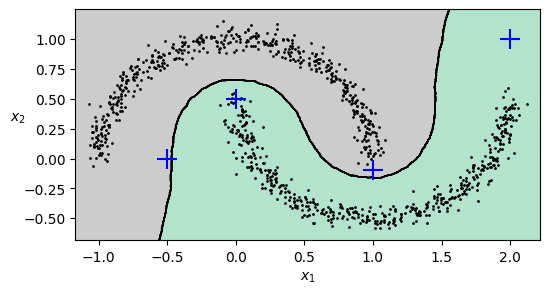

In [59]:
plt.figure(figsize=(6, 3))
plot_decision_boundaries(knn, X, show_centroids=False)
plt.scatter(X_new[:, 0], X_new[:, 1], c="b", marker="+", s=200, zorder=10)
plt.show()

In [60]:
# Introduce max distance using kneighbors(), where instances that are far from clusters are classified as anomalies

y_dist, y_pred_idx = knn.kneighbors(X_new, n_neighbors=1)
y_pred = dbscan.labels_[dbscan.core_sample_indices_][y_pred_idx]
y_pred[y_dist > 0.2] = -1
y_pred.ravel()

array([-1,  0,  1, -1])

- DBSCAN is a very simple yet powerful algorithm
- Capable of identifying any number of clusters of any shape
- However, it does not scale well to large datasets

### Other Clustering Algorithms

#### Agglomerative clustering

- A bottom-up hierarchical clustering algorithm
  - Start with:
    - every data point as its own cluster
  - Then repeatedly:
    - merge the two closest clusters
  - until:
    - only one cluster remains or desired number of clusters is reached

In [61]:
from sklearn.cluster import AgglomerativeClustering

X = np.array([0, 2, 5, 8.5]).reshape(-1, 1)
agg = AgglomerativeClustering(linkage="complete").fit(X)

def learned_parameters(estimator):
    return [attrib for attrib in dir(estimator)
            if attrib.endswith("_") and not attrib.startswith("_")]

In [62]:
learned_parameters(agg)

['children_',
 'labels_',
 'n_clusters_',
 'n_connected_components_',
 'n_features_in_',
 'n_leaves_']

In [63]:
agg.children_

array([[0, 1],
       [2, 3],
       [4, 5]])

#### BIRCH

- Designed for very large datasets
- Builds a tree structure containing jsut enough information to quickly assign each new instance to a cluster, without having to store all the instance in the tree

#### Mean-shift

- Not suited for large dataset
- Clustering algorithm that finds clusters by moving points toward high-density regions
  - repeatedly moves toward the densest nearby area
  - eventually converges to a density peak

#### Affinity propagation

- Clustering algorithm where data points communicate with each other to decide which points should become cluster centers (called exemplars)
- Similar to k-means, but dont have to pick a number of clusters ahead of time
- Not suitable for large datasets

#### Spatial clustering

- A family of clustering approaches designed for data with geographic or spatial structure (points in 2D/3D space, maps, coordinates, etc.)
- Does not scale well to large numbers of instances, and it does not behave well when the clusters have very different sizes

In [64]:
from sklearn.cluster import SpectralClustering

X, y = make_moons(n_samples=1000, noise=0.05)

In [65]:
sc1 = SpectralClustering(n_clusters=2, gamma=100, random_state=42)
sc1.fit(X)

SpectralClustering(gamma=100, n_clusters=2, random_state=42)

In [66]:
sc1.affinity_matrix_.round(2)

array([[1.  , 0.  , 0.  , ..., 0.  , 0.  , 0.  ],
       [0.  , 1.  , 0.  , ..., 0.  , 0.  , 0.  ],
       [0.  , 0.  , 1.  , ..., 0.  , 0.  , 0.  ],
       ...,
       [0.  , 0.  , 0.  , ..., 1.  , 0.52, 0.  ],
       [0.  , 0.  , 0.  , ..., 0.52, 1.  , 0.  ],
       [0.  , 0.  , 0.  , ..., 0.  , 0.  , 1.  ]])

In [67]:
sc2 = SpectralClustering(n_clusters=2, gamma=1, random_state=42)
sc2.fit(X)

SpectralClustering(gamma=1, n_clusters=2, random_state=42)

In [68]:
def plot_spectral_clustering(sc, X, size, alpha, show_xlabels=True,
                             show_ylabels=True):
    plt.scatter(X[:, 0], X[:, 1], marker='o', s=size, c='gray', alpha=alpha)
    plt.scatter(X[:, 0], X[:, 1], marker='o', s=30, c='w')
    plt.scatter(X[:, 0], X[:, 1], marker='.', s=10, c=sc.labels_, cmap="Paired")

    if show_xlabels:
        plt.xlabel("$x_1$")
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)
    plt.title(f"RBF gamma={sc.gamma}")

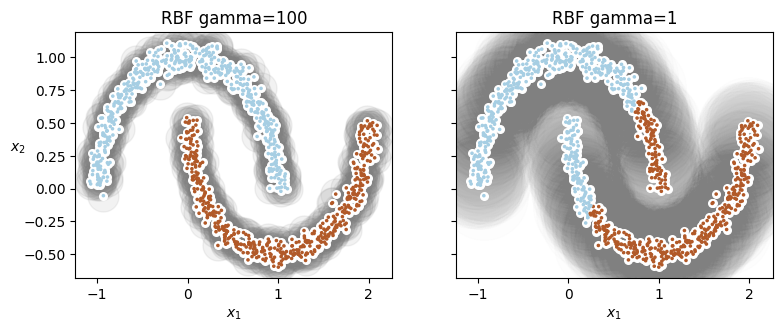

In [69]:
plt.figure(figsize=(9, 3.2))

plt.subplot(121)
plot_spectral_clustering(sc1, X, size=500, alpha=0.1)

plt.subplot(122)
plot_spectral_clustering(sc2, X, size=4000, alpha=0.01, show_ylabels=False)

plt.show()

## Gaussian Mixtures

In [70]:
# Generate the same dataset as earliers with three ellipsoids

X1, y1 = make_blobs(n_samples=1000, centers=((4, -4), (0, 0)), random_state=42)
X1 = X1.dot(np.array([[0.374, 0.95], [0.732, 0.598]]))
X2, y2 = make_blobs(n_samples=250, centers=1, random_state=42)
X2 = X2 + [6, -8]
X = np.r_[X1, X2]
y = np.r_[y1, y2]

In [71]:
from sklearn.mixture import GaussianMixture

gm = GaussianMixture(n_components=3, n_init=10, random_state=42)
gm.fit(X)

GaussianMixture(n_components=3, n_init=10, random_state=42)

In [72]:
gm.weights_

array([0.40005972, 0.20961444, 0.39032584])

In [73]:
gm.means_

array([[-1.40764129,  1.42712848],
       [ 3.39947665,  1.05931088],
       [ 0.05145113,  0.07534576]])

In [74]:
gm.covariances_

array([[[ 0.63478217,  0.72970097],
        [ 0.72970097,  1.16094925]],

       [[ 1.14740131, -0.03271106],
        [-0.03271106,  0.95498333]],

       [[ 0.68825143,  0.79617956],
        [ 0.79617956,  1.21242183]]])

In [75]:
gm.converged_

True

In [76]:
# Number of iterations taken to converge
gm.n_iter_

4

In [77]:
# For hard clustering
gm.predict(X)

array([2, 2, 0, ..., 1, 1, 1])

In [78]:
# For soft clustering
gm.predict_proba(X).round(3)

array([[0.   , 0.023, 0.977],
       [0.001, 0.016, 0.983],
       [1.   , 0.   , 0.   ],
       ...,
       [0.   , 1.   , 0.   ],
       [0.   , 1.   , 0.   ],
       [0.   , 1.   , 0.   ]])

- Gaussian Mixture Model is a generative model, it can sample new instances from it
- Sampled sequentially from each other

In [79]:
X_new, y_new = gm.sample(6)
X_new

array([[-2.32491052,  1.04752548],
       [-1.16654983,  1.62795173],
       [ 1.84860618,  2.07374016],
       [ 3.98304484,  1.49869936],
       [ 3.8163406 ,  0.53038367],
       [ 0.38079484, -0.56239369]])

In [80]:
y_new

array([0, 0, 1, 1, 1, 2])

- Can estimate the log of the probability density function (PDF) at any location using the score_samples() method
- The greater the score, the higher the density

In [81]:
gm.score_samples(X).round(2)

array([-2.61, -3.57, -3.33, ..., -3.51, -4.4 , -3.81])

Let's check that the PDF integrates to 1 over the whole space. We just take a large square around the clusters, and chop it into a grid of tiny squares, then we compute the approximate probability that the instances will be generated in each tiny square (by multiplying the PDF at one corner of the tiny square by the area of the square), and finally summing all these probabilities). The result is very close to 1:

In [82]:
resolution = 100
grid = np.arange(-10, 10, 1 / resolution)
xx, yy = np.meshgrid(grid, grid)
X_full = np.vstack([xx.ravel(), yy.ravel()]).T

pdf = np.exp(gm.score_samples(X_full))
pdf_probas = pdf * (1 / resolution) ** 2
pdf_probas.sum()

np.float64(0.9999999999225088)

- Plot shows cluster means, decision boundaries (dashed lines), and the density contour of this model

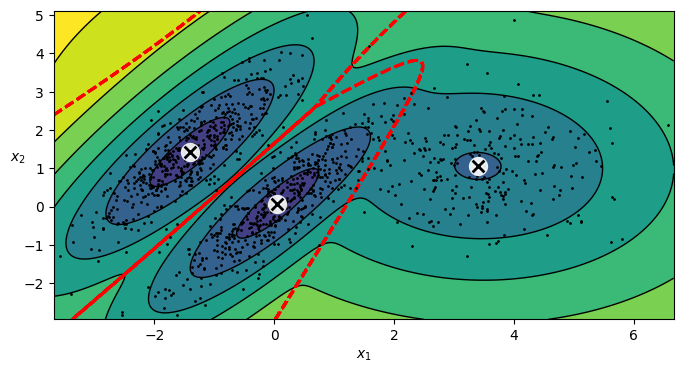

In [83]:
from matplotlib.colors import LogNorm

def plot_gaussian_mixture(clusterer, X, resolution=1000, show_ylabels=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = -clusterer.score_samples(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z,
                 norm=LogNorm(vmin=1.0, vmax=30.0),
                 levels=np.logspace(0, 2, 12))
    plt.contour(xx, yy, Z,
                norm=LogNorm(vmin=1.0, vmax=30.0),
                levels=np.logspace(0, 2, 12),
                linewidths=1, colors='k')

    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contour(xx, yy, Z,
                linewidths=2, colors='r', linestyles='dashed')

    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)
    plot_centroids(clusterer.means_, clusterer.weights_)

    plt.xlabel("$x_1$")
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)

plt.figure(figsize=(8, 4))

plot_gaussian_mixture(gm, X)

plt.show()

You can impose constraints on the covariance matrices that the algorithm looks for by setting the covariance_type hyperparameter:

- `spherical`: all clusters must be spherical, but they can have different diameters (i.e., different variances).
- `diag`: clusters can take on any ellipsoidal shape of any size, but the ellipsoid's axes must be parallel to the axes (i.e., the covariance matrices must be diagonal).
- `tied`: all clusters must have the same shape, which can be any ellipsoid (i.e., they all share the same covariance matrix).
"full" (default): no constraint, all clusters can take on any ellipsoidal shape of any size.

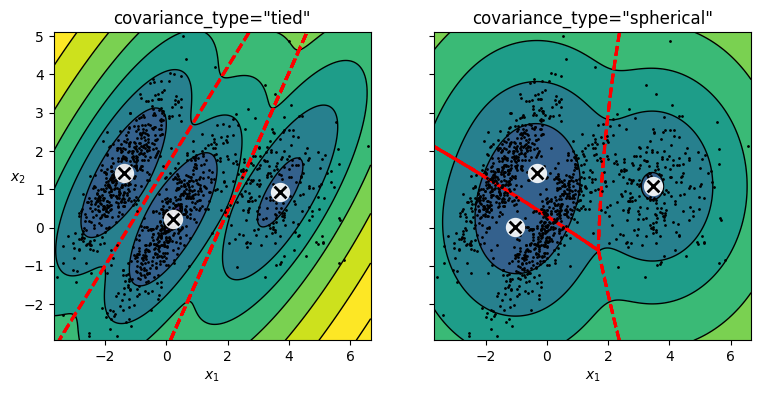

In [84]:
gm_full = GaussianMixture(n_components=3, n_init=10,
                          covariance_type="full", random_state=42)
gm_tied = GaussianMixture(n_components=3, n_init=10,
                          covariance_type="tied", random_state=42)
gm_spherical = GaussianMixture(n_components=3, n_init=10,
                               covariance_type="spherical", random_state=42)
gm_diag = GaussianMixture(n_components=3, n_init=10,
                          covariance_type="diag", random_state=42)
gm_full.fit(X)
gm_tied.fit(X)
gm_spherical.fit(X)
gm_diag.fit(X)

def compare_gaussian_mixtures(gm1, gm2, X):
    plt.figure(figsize=(9, 4))

    plt.subplot(121)
    plot_gaussian_mixture(gm1, X)
    plt.title(f'covariance_type="{gm1.covariance_type}"')

    plt.subplot(122)
    plot_gaussian_mixture(gm2, X, show_ylabels=False)
    plt.title(f'covariance_type="{gm2.covariance_type}"')

compare_gaussian_mixtures(gm_tied, gm_spherical, X)

plt.show()

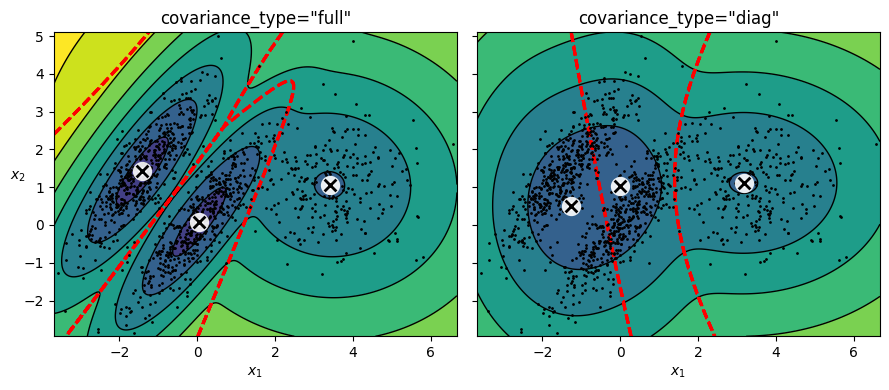

In [85]:
compare_gaussian_mixtures(gm_full, gm_diag, X)
plt.tight_layout()
plt.show()

### Using Gaussian Mixtures for Anomaly Detection

- Any instance located in a low-density region can be considered an anomaly

In [86]:
# Using the fourth percentile lowest density as the threshold

densities = gm.score_samples(X)
density_threshold = np.percentile(densities, 2)
anomalies = X[densities < density_threshold]

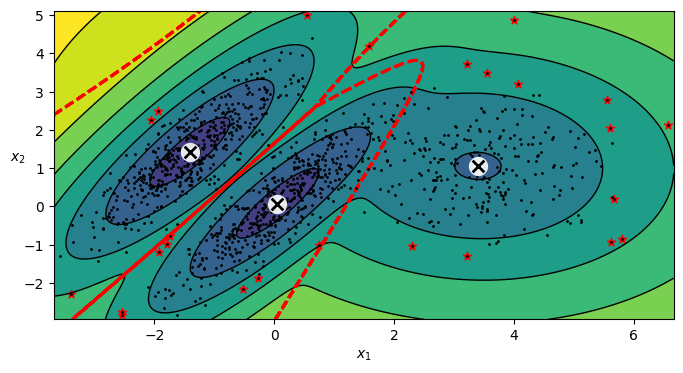

In [87]:
plt.figure(figsize=(8, 4))

plot_gaussian_mixture(gm, X)
plt.scatter(anomalies[:, 0], anomalies[:, 1], color='r', marker='*')
plt.ylim(top=5.1)

plt.show()